# Detection-head catalog on real Euclid Q1 tiles: foundation photometry versus Tractor and MER

This notebook compares three photometric measurements of **the same detection-head source list** on real Euclid Q1 pixels:

- **JAISP foundation prior**: the calibrated mixture photometer (`runs/q1_mixture_calibrated/priors.pt`, foundation mode) measuring all ten Rubin+Euclid bands jointly.
- **JAISP image prior**: the same photometer with the raw-VIS-pixel prior. It isolates what the foundation features add.
- **Tractor VIS profile**: the upstream SEP + chi-squared profile ladder from Nima Chartab's `euclid-forced-photometry` package with GRID PSFs in every band, following the linked notebook, followed by flux-only forced photometry in VIS/Y/J/H.

All three use identical archive science pixels, variance, flag masks (`INVALID|SAT|NO_DATA`, `STARSIGNAL`) and nearest GRID-PSF stamps. The source list is the v11 CenterNet detector (confidence 0.3) and every position is the frozen anchored-astrometry VIS-canonical centroid, sampled through each band's own WCS; Tractor's positions are frozen at the same values at every optimisation stage. MER fluxes are **position-matched within 0.5″** and act as a pipeline cross-check, not truth: `flux_vis_psf` for MER stars, `flux_vis_sersic` otherwise, and `flux_{y,j,h}_templfit` (T-PHOT) in NISP.

The sample is 28 non-overlapping 108″ tiles: 19 in patch 25 (held out from the detection and astrometry heads) and 9 in the photometry prior's RA test partition; none overlaps a tile whose scenes trained or validated the prior. The foundation was pretrained on all Q1 tiles. Rubin fluxes are measured but have no catalog reference here.

In [1]:
from pathlib import Path
import sys, os, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'models/photometry/self_supervised').is_dir())
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
os.chdir(ROOT)
from models.photometry.self_supervised.detcat import report
from models.photometry.self_supervised.detcat.common import OUT
pd.set_option('display.width',200); pd.set_option('display.max_columns',40)

## Pipeline provenance

Steps (modules in `models/photometry/self_supervised/detcat/`): `select_tiles` → `sources` (detections + astrometry) → `fetch` (IRSA cutouts, flags, GRID PSFs) → `prepare` (shared masks, scene geometry; verifies archive pixels equal the local tiles) → `photometer` (ours) and `tractor_run` (isolated Tractor environment) → `mer` (TAP query and matching) → `report`.

In [2]:
tiles=json.load(open(OUT/'tiles.json'))['tiles']
print(f"{len(tiles)} tiles, {sum(t['detections'] for t in tiles)} detections;", pd.Series([t['partition'] for t in tiles]).value_counts().to_dict())
prep=json.load(open(OUT/'prepare_status.json'))
print('archive pixels identical to local tiles in every region:', all(r['pixel_identity']['aligned'] and r['pixel_identity']['max_abs_diff']==0 for r in prep))
print('photometrable detections:', sum(r['n_inside_valid'] for r in prep), 'of', sum(r['n_sources'] for r in prep))
display(pd.DataFrame(json.load(open(OUT/'photometry_status.json'))).describe().loc[['count','mean','min','max']].round(1))
tractor=json.load(open(OUT/'tractor_status.json')); print(json.dumps(tractor['protocol'],indent=1)[:900])
counts=pd.DataFrame([r['counts'] for r in tractor['regions'] if 'counts' in r]).sum(); print('Tractor profile classes over all tiles:'); display(counts.to_frame('sources').T)
meta=json.load(open(OUT/'region_000/metadata.json')); print('detector:', meta['detection_config']); print('astrometry:', meta['astrometry'])

28 tiles, 6558 detections; {'patch25': 19, 'ra_test': 9}
archive pixels identical to local tiles in every region: True
photometrable detections: 5339 of 6558


,region,sources,usable,measured,failed
count,28.0,28.0,28.0,28.0,28.0
mean,13.5,234.2,190.7,190.7,0.0
min,0.0,171.0,125.0,125.0,0.0
max,27.0,298.0,243.0,243.0,0.0


{
 "upstream": {
  "repository": "https://github.com/NimaChartab/euclid-forced-photometry",
  "commit": "a6bde3d405fda2af980d898fc06790312d8f1c9c",
  "files": "src/, LICENSE, README.md, pyproject.toml; unchanged upstream snapshot"
 },
 "models": "Upstream full VIS profile ladder (point, simple, exp, dev, composite, guarded Sersic tier); SEP blobs and segments",
 "positions": "Detection-head sources at anchored-astrometry positions, frozen at every optimization stage",
 "psf": "Per-source nearest GRID-PSF stamp in every Euclid band",
 "sky": "Constant zero sky (background-subtracted MER mosaics), as upstream",
 "flux_solver": "Tractor optimize_forced_photometry, brightness only, formal errors from inverse variance",
 "units": "Native counts converted with image MAGZERO to microJansky"
}
Tractor profile classes over all tiles:


,PointSource,SimpleGalaxy,ExpGalaxy,DevGalaxy,CompositeGalaxy,SersicGalaxy,Unblobbed
sources,1611,23,2638,844,931,316,195


detector: {'encoder_ckpt': 'models/checkpoints/jaisp_v11_q1_soft/checkpoint_best.pt', 'centernet_ckpt': 'checkpoints/q1_detection_v11/centernet_vis_sep.pt', 'model_type': 'centernet', 'conf_threshold': 0.3, 'nms_kernel': 7, 'spike_veto_width': 0.0, 'spike_veto_radius': 0, 'spike_veto_min_star_area': 20, 'bright_rescue': False, 'bright_rescue_nsig': 2.5, 'bright_rescue_min_area': 45, 'bright_rescue_min_radius': 5.0, 'bright_rescue_min_peak_snr': 8.0, 'bright_rescue_match_scale': 1.5, 'bright_rescue_match_min': 8.0, 'bright_rescue_match_max': 35.0, 'bright_rescue_max_per_tile': 32, 'bright_rescue_score': 0.95, 'n_tiles': 790, 'n_errors': 0, 'n_vetoed': 0, 'n_bright_rescue': 0}
astrometry: models/checkpoints/latent_position_v11_anchored_v11labels_patchval25/best.pt


## Build the catalog and the summary tables

`collect` merges the per-tile products into `catalog_long.csv` (one row per detection, band and method) and `catalog_wide.csv`. The **paired sample** used for all method comparisons is: MER-matched within 0.5″ (primary match), measured by all three methods, and not a duplicate from the 6″ overlap between neighbouring tiles. ΔAB is `−2.5 log10(measured / MER)` and is defined only when both fluxes are positive; non-positive fractions are tabulated separately. The tile-level paired bootstrap resamples whole tiles, so correlated sources within a tile do not inflate the significance.

In [3]:
d=report.collect(); summary=report.summarize(d); boot=report.paired_bootstrap(d); stats=report.detection_statistics(d)
x=report.comparison_sample(d)
print('detections with photometry:', d.groupby(['region','source']).ngroups, '| paired MER-matched sources:', x.groupby(['region','source']).ngroups)
print('\nAll paired sources (positive-flux pairs, median offset, NMAD, non-positive fraction):')
display(summary[(summary.subset=='all')&(summary.mag_bin=='all')].pivot(index='band',columns='model',values=['n_positive','median_delta_ab','nmad_ab','nonpositive_fraction','chi_nmad']).round(3))
print('\nMER < 24.5, by class:')
display(summary[summary.subset.isin(['galaxies','stars'])&(summary.mag_bin=='all')].pivot_table(index=['band','subset'],columns='model',values=['n_positive','median_delta_ab','nmad_ab']).round(3))
print('\nTile-bootstrap differences (foundation minus other) with 95% intervals; negative NMAD difference favours the foundation head:')
display(boot.round(4))

detections with photometry: 6558 | paired MER-matched sources: 4732

All paired sources (positive-flux pairs, median offset, NMAD, non-positive fraction):


n_positive                         median_delta_ab                           nmad_ab                        nonpositive_fraction                          chi_nmad                       
model      foundation   image scarlet tractor      foundation  image scarlet tractor foundation  image scarlet tractor           foundation  image scarlet tractor foundation  image scarlet tractor
band                                                                                                                                                                                                
euclid_H       4686.0  4687.0  4645.0  4677.0          -0.027 -0.045  -0.067   0.008      0.137  0.141   0.172   0.156                0.003  0.002   0.011   0.004      0.736  0.754   0.967   0.900
euclid_J       4671.0  4671.0  4638.0  4664.0          -0.027 -0.044  -0.068   0.006      0.139  0.146   0.184   0.165                0.002  0.002   0.009   0.003      0.707  0.725   0.933   0.871
euclid_VIS     4697.0  4697.0  4679.0  4696.0          -0.073 -0.083  -0.092   0.000      0.125  0.138   0.242   0.125                0.000  0.000   0.004   0.000      1.824  1.876   3.156   1.984
euclid_Y       4674.0  4673.0  4633.0  4665.0          -0.039 -0.054  -0.068   0.017      0.151  0.155   0.206   0.185                0.001  0.001   0.010   0.003      0.627  0.637   0.828   0.755


MER < 24.5, by class:


median_delta_ab                        n_positive                            nmad_ab                       
model                    foundation  image scarlet tractor foundation   image scarlet tractor foundation  image scarlet tractor
band       subset                                                                                                              
euclid_H   galaxies          -0.027 -0.045  -0.067   0.008     4671.0  4672.0  4631.0  4662.0      0.137  0.142   0.173   0.157
           stars             -0.024 -0.023  -0.085   0.047       15.0    15.0    14.0    15.0      0.069  0.068   0.037   0.033
euclid_J   galaxies          -0.027 -0.044  -0.068   0.005     4658.0  4658.0  4626.0  4651.0      0.140  0.146   0.185   0.166
           stars              0.017  0.018  -0.055   0.050       13.0    13.0    12.0    13.0      0.027  0.028   0.034   0.050
euclid_VIS galaxies          -0.073 -0.084  -0.092   0.000     4679.0  4679.0  4661.0  4678.0      0.125  0.138   0.243   0.125
           stars             -0.055 -0.060  -0.108  -0.028       18.0    18.0    18.0    18.0      0.046  0.053   0.075   0.055
euclid_Y   galaxies          -0.039 -0.054  -0.068   0.016     4661.0  4660.0  4620.0  4652.0      0.152  0.155   0.206   0.185
           stars             -0.015 -0.014  -0.065   0.091       13.0    13.0    13.0    13.0      0.077  0.079   0.052   0.076


Tile-bootstrap differences (foundation minus other) with 95% intervals; negative NMAD difference favours the foundation head:


,band,comparison,metric,n,foundation,other,difference,ci_low,ci_high
0,euclid_VIS,foundation-tractor,nmad,4678,0.1247,0.1243,0.0004,-0.0078,0.0094
1,euclid_VIS,foundation-tractor,median,4678,-0.0727,0.0003,-0.0731,-0.0801,-0.0668
2,euclid_VIS,foundation-image,nmad,4678,0.1247,0.1370,-0.0124,-0.0162,-0.0075
3,euclid_VIS,foundation-image,median,4678,-0.0727,-0.0830,0.0103,0.0070,0.0136
4,euclid_VIS,scarlet-foundation,nmad,4678,0.2420,0.1247,0.1174,0.1088,0.1254
5,euclid_VIS,scarlet-foundation,median,4678,-0.0922,-0.0727,-0.0194,-0.0264,-0.0103
6,euclid_VIS,scarlet-tractor,nmad,4678,0.2420,0.1243,0.1178,0.1088,0.1272
7,euclid_VIS,scarlet-tractor,median,4678,-0.0922,0.0003,-0.0925,-0.1005,-0.0832
8,euclid_Y,foundation-tractor,nmad,4624,0.1506,0.1824,-0.0318,-0.0429,-0.0216
9,euclid_Y,foundation-tractor,median,4624,-0.0392,0.0168,-0.0560,-0.0630,-0.0482


## Measured minus MER versus magnitude

Each panel is one Euclid band. Points are individual sources; curves are the running median per 0.5 mag with the 16–84% band. Because MER is a pipeline measurement on the same mosaics with its own profile and blending choices, a smaller offset from MER is not proof of accuracy, but a smaller *scatter* at fixed magnitude and a flatter trend are what a better-behaved photometer should show.

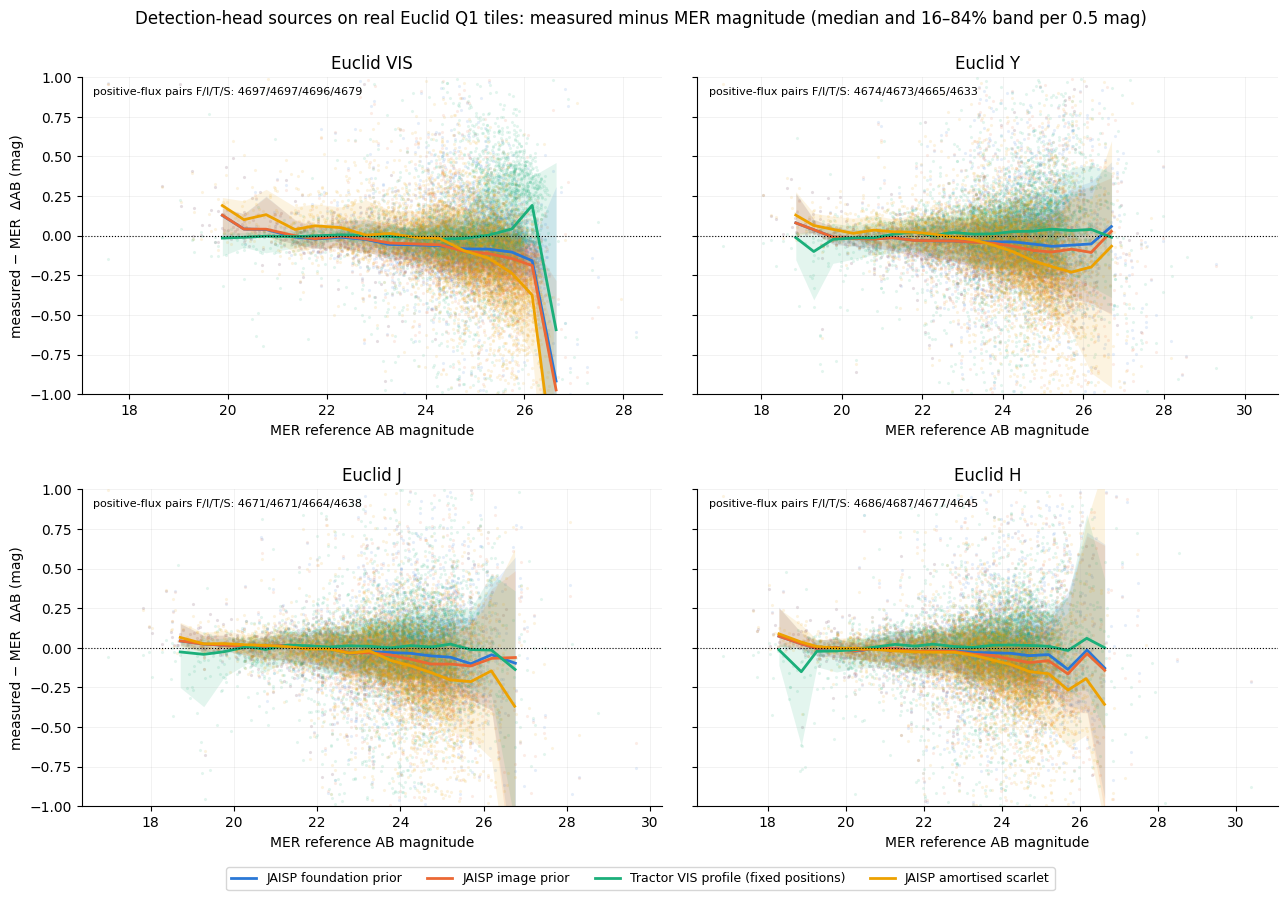

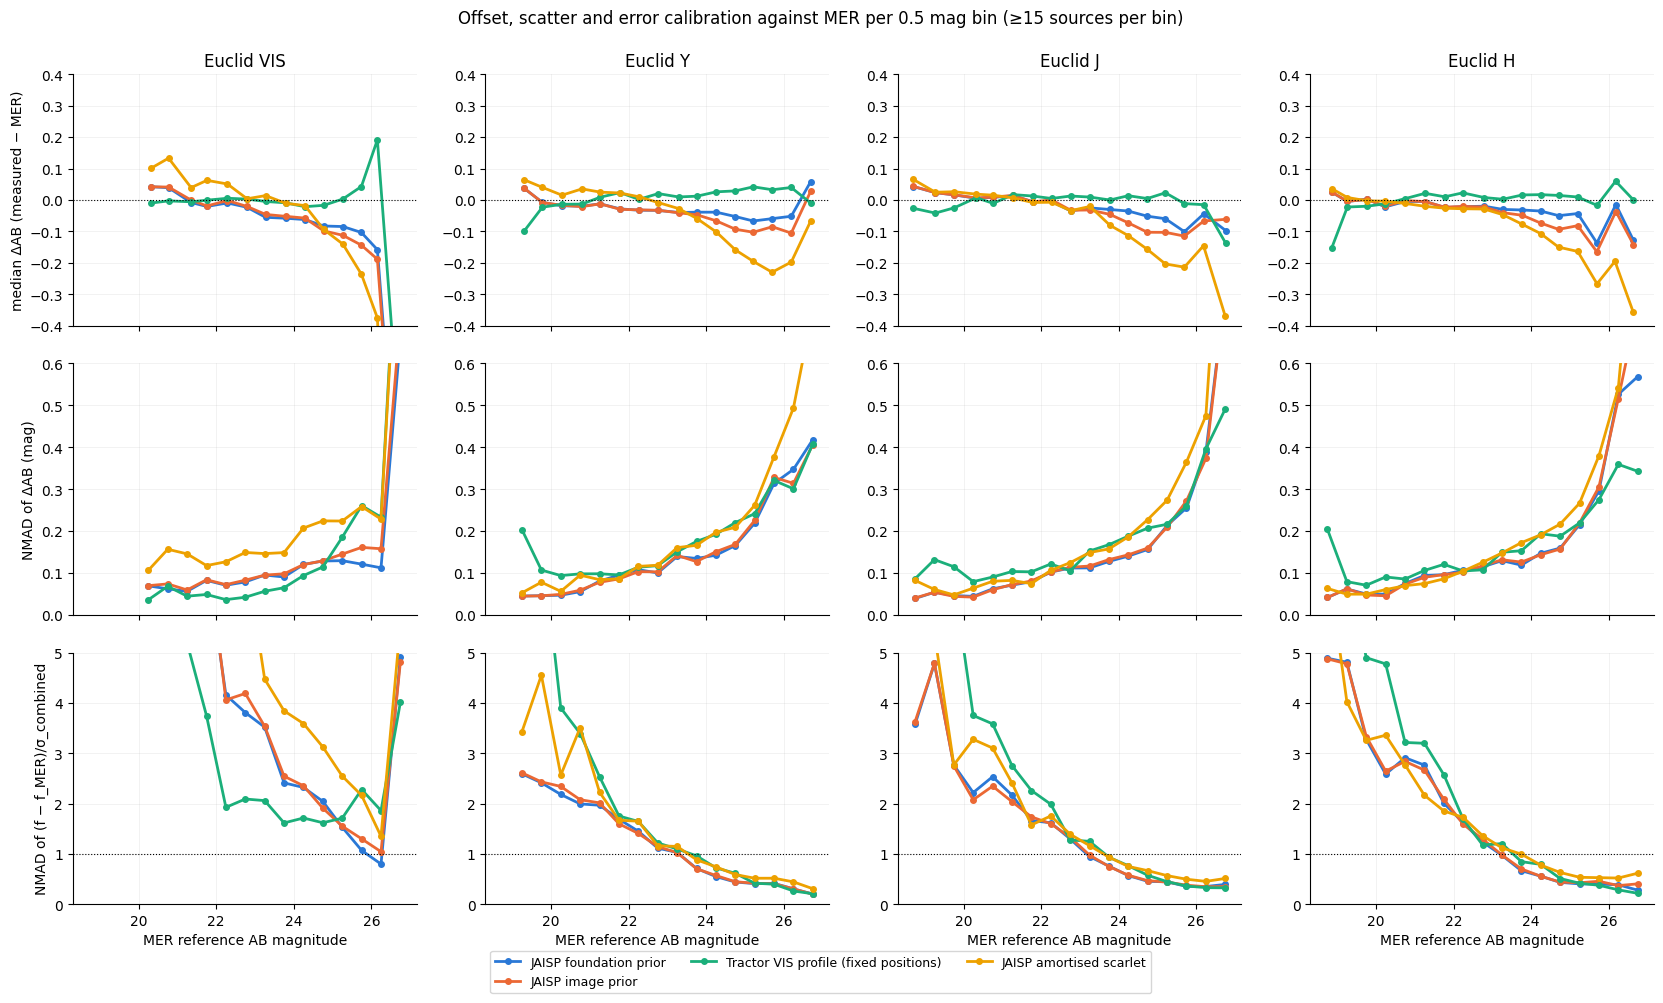

In [4]:
fig=report.fig_delta_vs_mag(d); plt.show(); fig=report.fig_scatter_vs_mag(d); plt.show()

## Method-to-method comparison on identical inputs

The y-axes here never involve MER: they are the direct magnitude differences between methods on the same pixels. The second row isolates the foundation-specific contribution by comparing against the image-prior control.

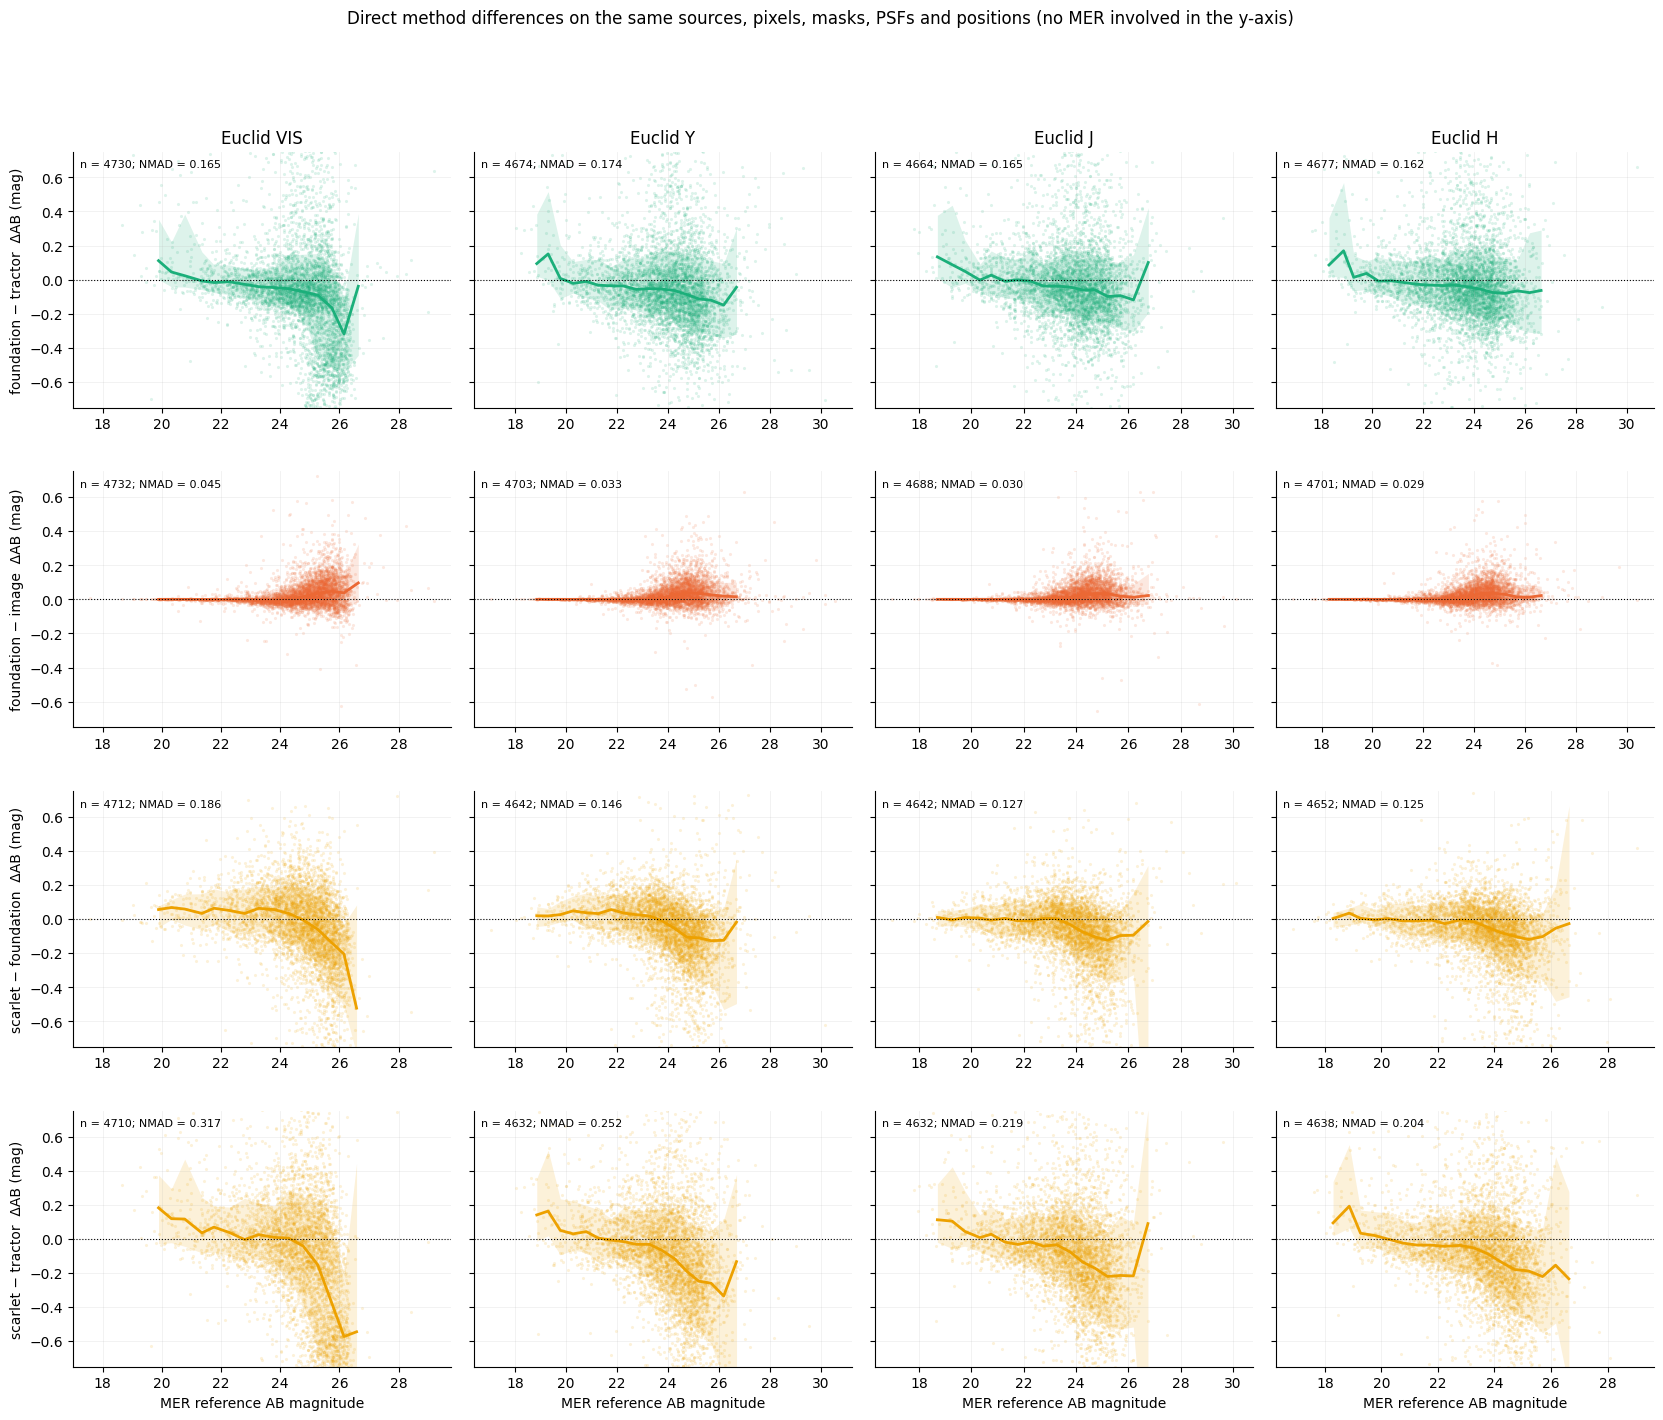

In [5]:
fig=report.fig_head_to_head(d); plt.show()

## Trends with crowding, size and class

For MER < 24.5 sources: offset against the distance to the nearest other MER source, against the MER semimajor axis (galaxies), and split by MER star/galaxy class.

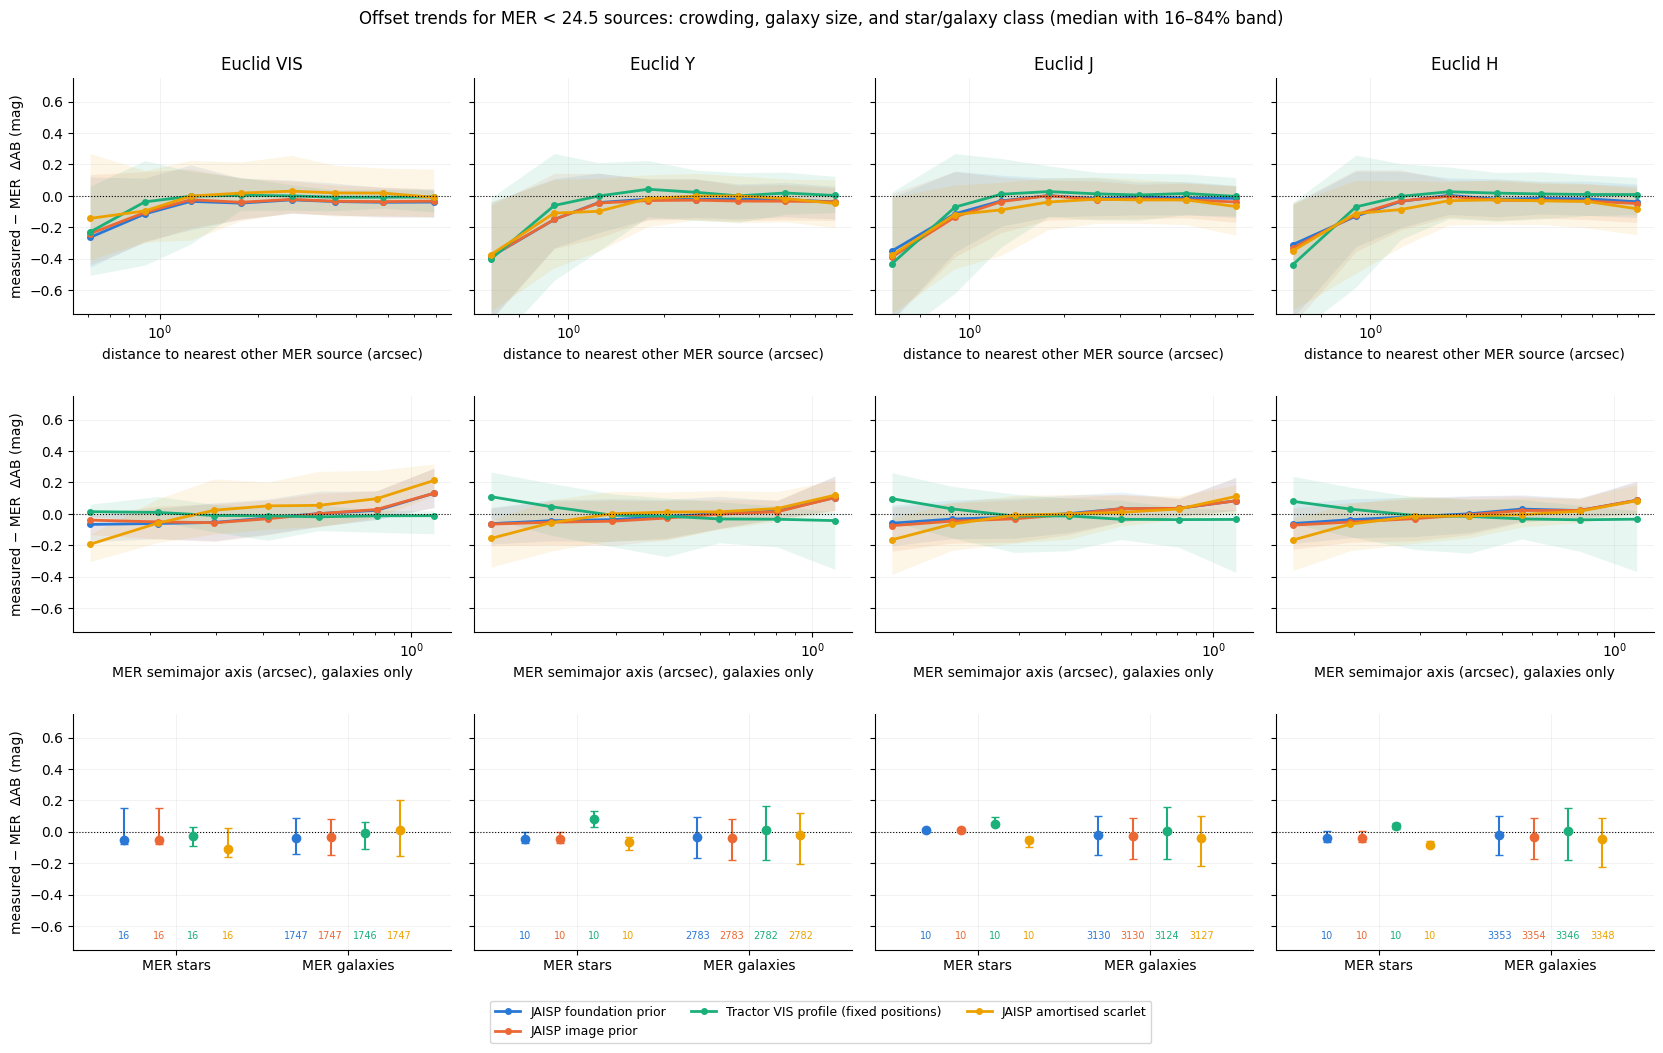

In [6]:
fig=report.fig_trends(d); plt.show()

## Colours

Colours cancel the zero-point and aperture conventions to first order and test whether band-dependent profiles behave consistently. Only sources with S/N > 10 in both bands enter.

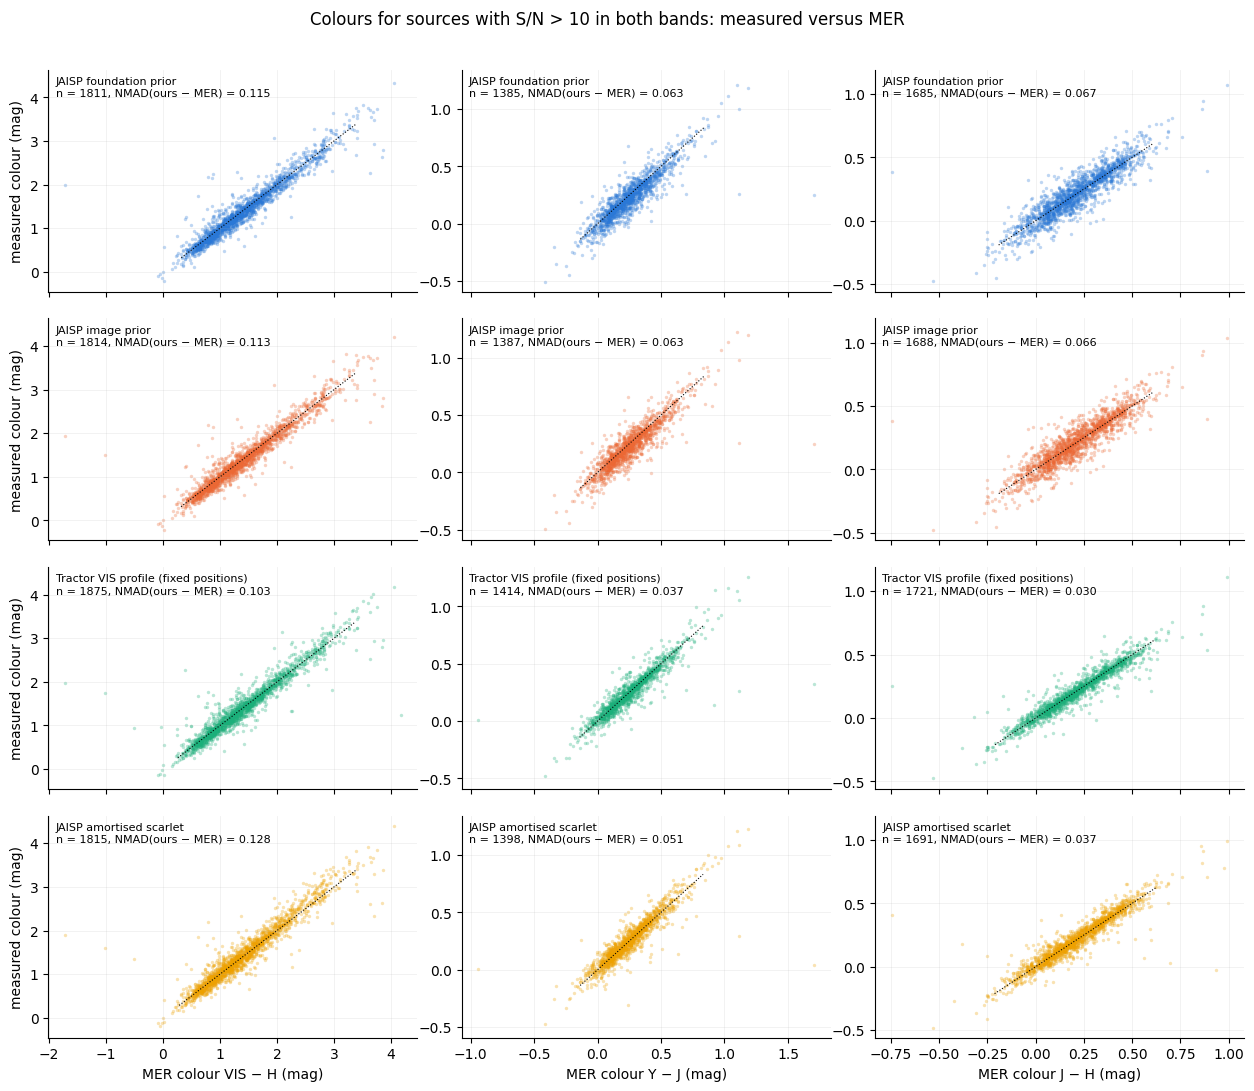

In [7]:
fig=report.fig_colors(d); plt.show()

## Detection head versus MER inside the photometered footprint

,mag_low,mag_high,mer_sources,completeness,detections,purity
0,17.0,17.5,8,0.875,0,NaN
1,17.5,18.0,3,0.667,0,NaN
2,18.0,18.5,5,1.000,0,NaN
3,18.5,19.0,5,1.000,2,1.000
4,19.0,19.5,18,0.833,4,1.000
5,19.5,20.0,25,0.960,11,1.000
6,20.0,20.5,32,0.969,28,1.000
7,20.5,21.0,51,0.961,34,0.971
8,21.0,21.5,62,1.000,60,0.983
9,21.5,22.0,83,0.964,80,0.988


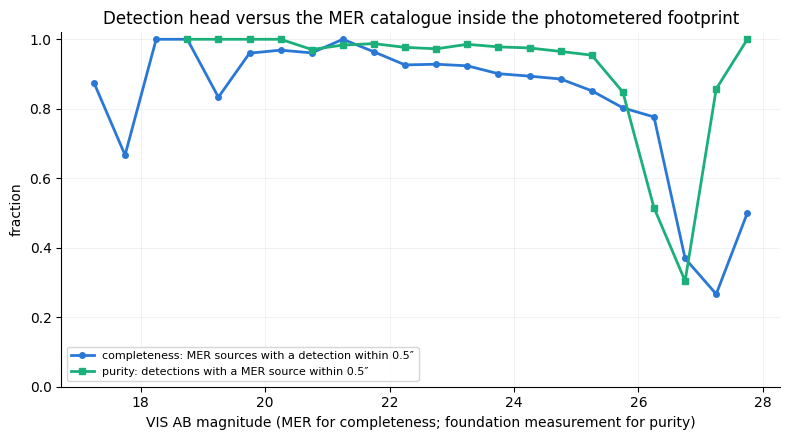

In [8]:
display(stats.round(3)); fig=report.fig_detection(stats); plt.show()

## Rubin bands

Rubin ugrizy are measured jointly with the Euclid bands by the foundation photometer at the same positions. There is no catalog reference here; the panels show the S/N reached, an internal i-band versus VIS consistency check (Rubin deep-coadd pixels are assumed to be in nanojansky), and the fraction of non-positive signed fluxes per band.

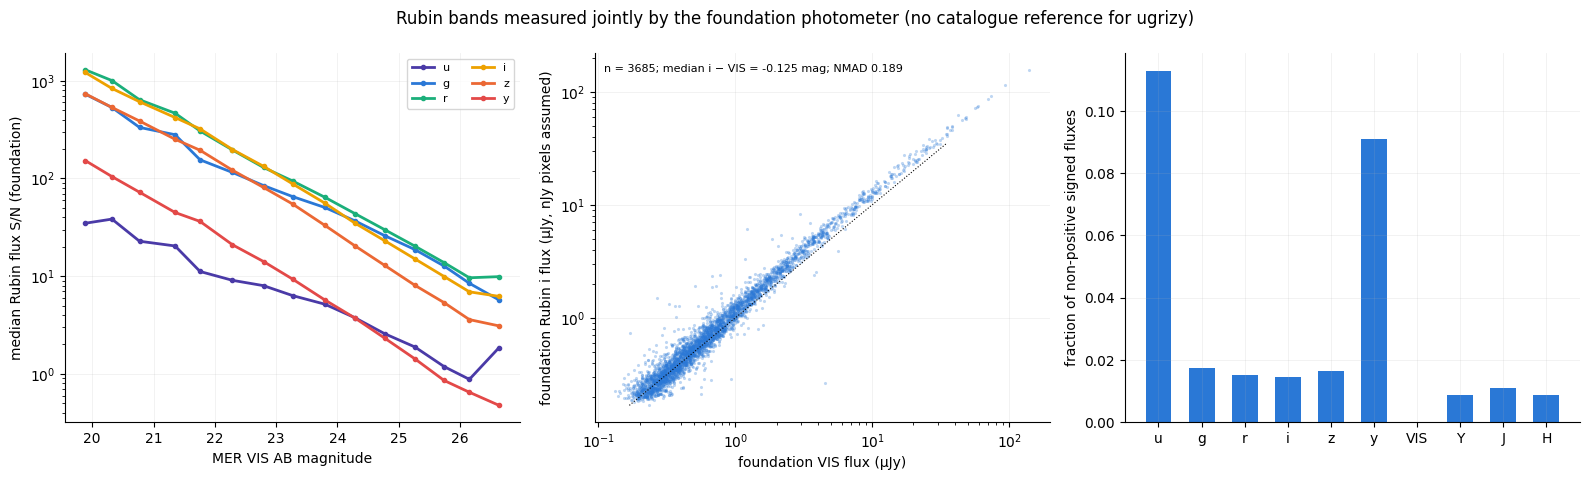

In [9]:
fig=report.fig_rubin(d); plt.show()

## Example scene

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v11 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2, compression=asinh50) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v11_q1_soft/checkpoint_best.pt


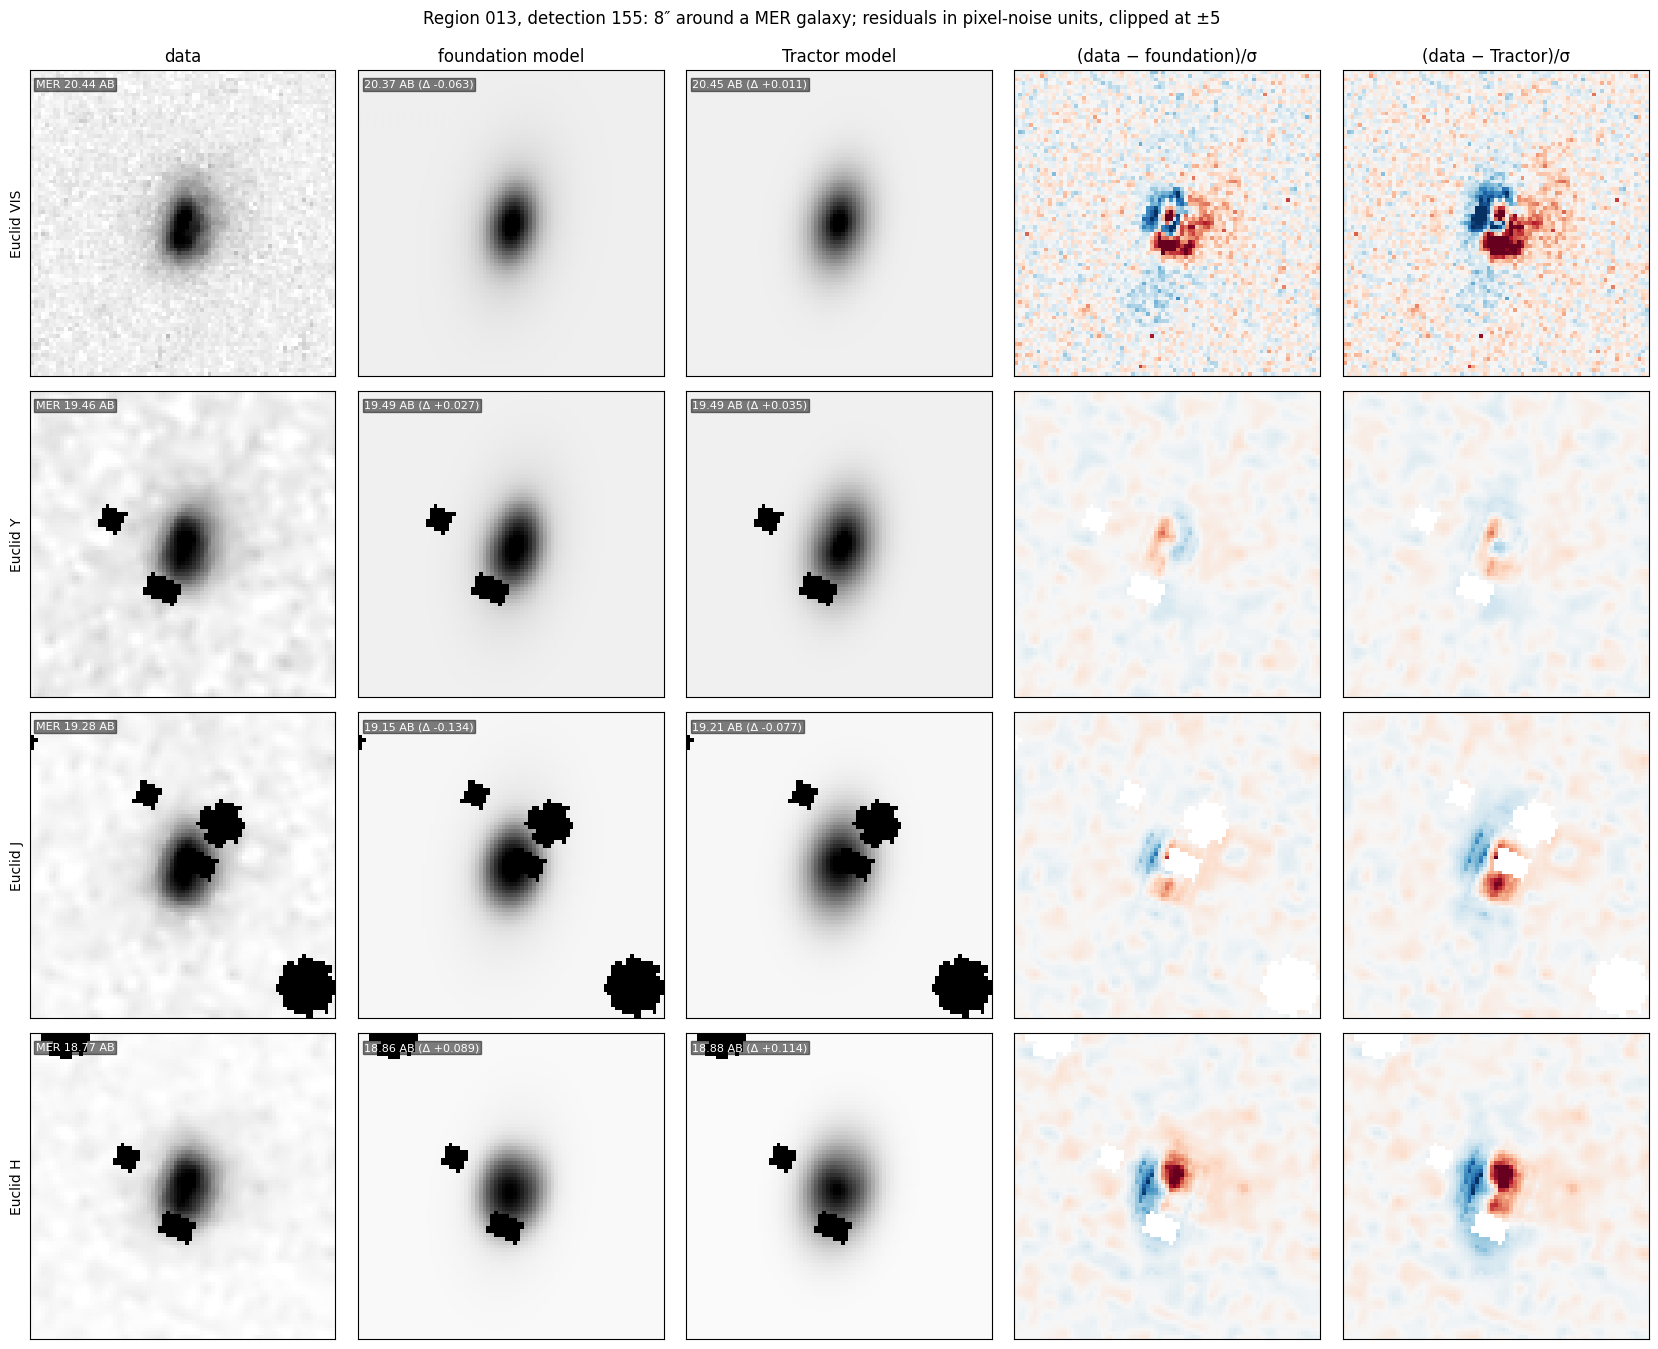

In [10]:
fig=report.fig_example(d); plt.show()

## Amortised scarlet head

`amortised_scarlet.py` is a learned scarlet-style photometer on top of the frozen foundation encoder: each source is a positive morphology on a 0.1″ tangent-plane grid, rendered through each band's explicit PSF (GRID stamps for Euclid, calibrated Gaussians for Rubin), with signed fluxes solved linearly exactly as in the mixture photometer. A small head reads the fused bottleneck window, the VIS stem window and the raw ten-band pixels at each source and outputs two centred, monotonically decreasing elliptical radial profiles (compact and extended), a per-band mixing weight for colour gradients, and a bounded perturbation map; two unrolled refinement steps feed the exact residual gradient back into the head. It is trained only on the scene residual (mean over bands of log χ²/dof) on 43 training tiles disjoint from the 28 comparison tiles, with no flux labels.

Two structural choices were forced by the known-flux injection benchmark, not by validation χ²: free-form morphologies let overlapping sources trade light without changing the residual (2.6× worse than the mixture on injections while matching its validation χ²), and a free constant background lets slightly too-broad templates inflate fluxes (+10 % bias at high S/N). The final head therefore uses monotone profiles and a fixed robust background (median of valid pixels farther than 1.5″ from every source). The same fixed background makes no difference to the mixture head on injections.

In [11]:
import glob
Q=ROOT/'models/photometry/self_supervised/runs/q1_mixture_calibrated'; A=ROOT/'models/photometry/self_supervised/runs/amortised_scarlet'
runs={'free-form morphology, free background (epoch 1)':'_scarlet_epoch1','monotone profiles, free background (epoch 1)':'_scarlet_v2_epoch1',
      'monotone, free background, lr 1e-3 (epoch 1)':'_scarlet_lr1e3_epoch1','monotone, fixed background (epoch 1)':'_scarlet_fixedbg_epoch1',
      'monotone, fixed background, no refinement (final)':'_scarlet_fixedbg_nostep','monotone, fixed background (final)':'_scarlet_fixedbg_final'}
rows=[]
base=pd.read_csv(Q/'injection_summary.csv')
for m in ('foundation','image','population'):
    b=base[base.model==m]; rows.append(dict(model=f'mixture {m} prior', mean_median_abs_frac_err=b.median_absolute_error.mean(), euclid=b[b.band.str.startswith('euclid')].median_absolute_error.mean(), rubin=b[b.band.str.startswith('rubin')].median_absolute_error.mean(), mean_bias=b.bias.mean()))
mf=pd.read_csv(Q/'injection_summary_mixture_fixedbg.csv'); b=mf[mf.model=='foundation_fixedbg']
rows.append(dict(model='mixture foundation prior, fixed background', mean_median_abs_frac_err=b.median_absolute_error.mean(), euclid=b[b.band.str.startswith('euclid')].median_absolute_error.mean(), rubin=b[b.band.str.startswith('rubin')].median_absolute_error.mean(), mean_bias=b.bias.mean()))
for label,sfx in runs.items():
    f=Q/f'injection_summary{sfx}.csv'
    if not f.exists(): continue
    b=pd.read_csv(f); b=b[b.model=='scarlet']
    rows.append(dict(model='scarlet: '+label, mean_median_abs_frac_err=b.median_absolute_error.mean(), euclid=b[b.band.str.startswith('euclid')].median_absolute_error.mean(), rubin=b[b.band.str.startswith('rubin')].median_absolute_error.mean(), mean_bias=b.bias.mean()))
print('Known-flux injections (128 blends, 256 sources, 10 bands): mean over bands of the median |fractional flux error| and of the median bias')
display(pd.DataFrame(rows).round(4))
for name in ('fixedbg','fixedbg_nostep'):
    h=json.load(open(A/name/'history.json')); print(name,'validation mean log(chi2/dof) per epoch:',[round(r['val'],4) for r in h],'| without refinement:',[round(r['val_no_refinement'],4) for r in h])
print('mixture foundation prior on the same validation scenes: -0.813')
inj=pd.read_csv(Q/'injection_summary_scarlet_fixedbg_final.csv'); print('final head per band:'); display(inj.pivot(index='band',columns='model',values=['median_absolute_error','bias']).round(3).xs('scarlet',axis=1,level=1).join(inj.pivot(index='band',columns='model',values=['median_absolute_error','bias']).round(3).xs('foundation',axis=1,level=1),lsuffix='_scarlet',rsuffix='_mixture'))
d_inj=pd.read_csv(Q/'injections_scarlet_fixedbg_final.csv'); d_inj['abs']=d_inj.fractional_error.abs()
for label,sel in [('Euclid',d_inj.band.str.startswith('euclid')),('Rubin',d_inj.band.str.startswith('rubin'))]:
    e=d_inj[sel]; print(label,'median |fractional error| by true S/N and by separation:')
    display(pd.concat([e.groupby([pd.cut(e.true_snr,[0,10,20,40,1000],),'model'],observed=True).abs.median().unstack()[['foundation','scarlet']].round(3),
                       e.groupby([pd.cut(e.separation_arcsec,[.4,.7,1,1.4]),'model'],observed=True).abs.median().unstack()[['foundation','scarlet']].round(3)]))

Known-flux injections (128 blends, 256 sources, 10 bands): mean over bands of the median |fractional flux error| and of the median bias


,model,mean_median_abs_frac_err,euclid,rubin,mean_bias
0,mixture foundation prior,0.1076,0.1247,0.0962,0.0317
1,mixture image prior,0.1093,0.1238,0.0996,0.0330
2,mixture population prior,0.1118,0.1308,0.0992,0.0397
3,"mixture foundation prior, fixed background",0.1094,0.1266,0.0979,0.0302
4,"scarlet: free-form morphology, free background...",0.2800,0.2136,0.3242,0.0638
5,"scarlet: monotone profiles, free background (e...",0.2054,0.2054,0.2053,0.1625
6,"scarlet: monotone, free background, lr 1e-3 (e...",0.1479,0.1472,0.1484,0.0919
7,"scarlet: monotone, fixed background (epoch 1)",0.1090,0.1291,0.0957,0.0069
8,"scarlet: monotone, fixed background, no refine...",0.2266,0.2417,0.2165,0.1626
9,"scarlet: monotone, fixed background (final)",0.1375,0.1332,0.1403,0.0742


fixedbg validation mean log(chi2/dof) per epoch: [-0.7929, -0.7942, -0.8011, -0.8025] | without refinement: [-0.6343, -0.6277, -0.6225, -0.6228]
fixedbg_nostep validation mean log(chi2/dof) per epoch: [-0.7531, -0.7745, -0.7842, -0.7865] | without refinement: [-0.7531, -0.7745, -0.7842, -0.7865]
mixture foundation prior on the same validation scenes: -0.813
final head per band:


,median_absolute_error_scarlet,bias_scarlet,median_absolute_error_mixture,bias_mixture
band,,,,
euclid_H,0.120,0.058,0.093,0.021
euclid_J,0.122,0.033,0.097,0.019
euclid_VIS,0.161,0.047,0.190,0.074
euclid_Y,0.130,0.029,0.119,0.052
rubin_g,0.138,0.097,0.077,0.026
rubin_i,0.120,0.096,0.059,0.019
rubin_r,0.122,0.086,0.072,0.021
rubin_u,0.172,0.070,0.150,0.013
rubin_y,0.153,0.115,0.123,0.047


Euclid median |fractional error| by true S/N and by separation:


model,foundation,scarlet
"(0.0, 10.0]",0.239,0.219
"(10.0, 20.0]",0.140,0.143
"(20.0, 40.0]",0.098,0.107
"(40.0, 1000.0]",0.054,0.090
"(0.4, 0.7]",0.119,0.173
"(0.7, 1.0]",0.119,0.122
"(1.0, 1.4]",0.111,0.119


Rubin median |fractional error| by true S/N and by separation:


model,foundation,scarlet
"(0.0, 10.0]",0.224,0.232
"(10.0, 20.0]",0.123,0.135
"(20.0, 40.0]",0.068,0.116
"(40.0, 1000.0]",0.034,0.117
"(0.4, 0.7]",0.101,0.166
"(0.7, 1.0]",0.085,0.135
"(1.0, 1.4]",0.088,0.118


## Findings

Sample: 28 non-overlapping tiles, 6558 detections, 5339 photometered by every method, **4732 MER-matched sources in the paired comparison** (about 4700 positive-flux pairs per band). All numbers below are from `summary.csv` and `paired_bootstrap.csv`; intervals are 95% tile-bootstrap intervals.

**Scatter against MER (NMAD of ΔAB, all paired sources).** Foundation / image prior / Tractor: VIS 0.125 / 0.138 / 0.125; Y 0.151 / 0.155 / 0.185; J 0.139 / 0.146 / 0.165; H 0.137 / 0.141 / 0.156 mag. Foundation minus Tractor: VIS +0.000 [−0.008, +0.009]; Y −0.034 [−0.043, −0.023]; J −0.026 [−0.035, −0.018]; H −0.019 [−0.027, −0.012]. In the three NISP bands the foundation photometer is significantly closer to the MER template fits than the fixed-VIS-profile Tractor measurement; in VIS the two are indistinguishable. Foundation minus image prior: VIS −0.012 [−0.016, −0.008]; Y −0.003 [−0.009, +0.001]; J −0.006 [−0.011, −0.003]; H −0.004 [−0.009, −0.001]. The foundation-specific gain over the raw-pixel prior is small but resolved in VIS, J and H; most of the NISP advantage over Tractor comes from the band-dependent mixture profiles, not from the foundation features.

**Dependence on magnitude.** At the bright end (MER < 22) the NISP scatter is about 0.05 mag for both JAISP priors versus about 0.10 mag for Tractor, while in VIS Tractor is tighter (0.035 versus 0.07 mag), as expected when both Tractor and MER fit Sérsic-type profiles to the same VIS pixels. Fainter than VIS 24.5 the foundation scatter stays at 0.12–0.13 mag while Tractor rises to 0.19–0.26 mag.

**Systematic offset.** Tractor has essentially zero median offset from MER in every band (0.000 to +0.017). Both JAISP priors measure *more* flux than MER: medians of −0.073 (VIS), −0.039 (Y), −0.027 (J), −0.028 (H) mag, growing with magnitude (VIS: −0.02 at 22–23, −0.08 at 24–25, −0.16 at 26–27) and present for isolated galaxies as well, so crowding is not the cause. Candidate explanations are the free constant background per 12″ scene (MER mosaics are already background-subtracted and Tractor fixes the sky at zero) and positive-only profile selection on noisy pixels favouring extended components; separating these needs an injection test on these tiles, which this notebook does not do. MER is not truth, so the offset is a convention difference until that test is done.

**Error calibration.** The NMAD of (f − f_MER)/σ_combined is 1.8–2.0 in VIS and 0.6–0.75 in NISP for every method: bright sources are dominated by profile systematics (χ NMAD 3–5 brighter than 21), and faint NISP sources have combined errors that are too large, consistent with the inflated archive NISP RMS maps already seen in the real-MER notebook.

**Trends.** For pairs closer than 1″ all three methods are 0.2–0.4 mag brighter than MER (different deblending). No significant trend with MER galaxy size for the JAISP priors; Tractor is 0.1 mag fainter than MER for the smallest NISP galaxies. Only 16 MER-classified stars (point_like_prob > 0.96) brighter than 24.5 fall in the sample, so the star rows are not informative.

**Detection head.** Completeness relative to MER inside the photometered footprint is 0.93 at VIS 22–23.5, 0.90 at 23.5–24.5 and 0.85 at 25–25.5; purity is ≥ 0.97 to VIS 25 and 0.85 at 25.5–26. Tractor's ladder assigned 1611 point sources, 2638 exponential, 844 de Vaucouleurs, 931 composite and 316 Sérsic profiles; 195 detections fell outside every SEP blob and were measured as point sources.

**Rubin.** Median S/N of the joint ten-band fit is 18–24 in g, r, i, 10 in z and about 2 in u and y. The median i − VIS colour of −0.125 mag for S/N > 10 sources is consistent with the Rubin deep-coadd pixels being in nanojansky; this assumption is not otherwise verified.

**Caveats.** MER fluxes are pipeline measurements on the same mosaics with their own profiles, apertures and deblending. The foundation encoder was pretrained on every Q1 tile, and the detection and astrometry heads saw the RA-test tiles during pseudo-label training; only the patch-25 tiles are unseen by those heads, and only the mixture prior is held out on all 28 tiles. Tractor was run with positions frozen at our astrometry, so its upstream position refinement and the Tractor error-inflation calibration were not exercised.

**Amortised scarlet head (first iteration).** On the 128 known-flux blends the final fixed-background head reaches a mean median |fractional error| of 0.138 (mixture: 0.108): better than the mixture at S/N < 20 in Euclid, worse at S/N > 40 (0.090 vs 0.054) and for pairs closer than 0.7″ (0.173 vs 0.119), with a +3 to +11 % bias. Its epoch-1 checkpoint scored 0.109 with ≤ 1 % mean bias, while validation χ² kept improving to epoch 4: the residual objective selects for fitting real-galaxy wings, which on compact simulated profiles turns into a flux excess, so validation χ² alone cannot select a photometry head. On the 4732 real MER-matched sources the final head is worse than the mixture against MER in every band (NMAD VIS 0.242 vs 0.125; Y 0.206 vs 0.151; J 0.184 vs 0.139; H 0.172 vs 0.137, all intervals excluding zero) and worse than Tractor in NISP by 0.02 mag, with offsets of −0.07 to −0.09 mag. Brighter than MER 22 it matches the mixture in NISP (0.064–0.088) and beats Tractor there, but its VIS fluxes are 0.05–0.15 mag fainter than the mixture's with a worse VIS residual (reduced χ² 0.65 vs 0.53), so the two-profile VIS morphology on a 0.1″ grid under-fits bright galaxies. Ablations: free-form morphologies gave 0.280 on injections (light trades freely between blended sources), a free constant background gave +10 % bias even with monotone profiles, and removing the two unrolled refinement steps gave 0.227, so the per-scene residual-gradient steps carry most of the accuracy. Measuring the real tiles with the epoch-1 checkpoint instead (`region_*/scarlet_epoch1_fluxes.csv`) removes most of the offset (VIS 0.000, NISP −0.03) and trims the NISP scatter to 0.167–0.189, but the VIS scatter stays at 0.240 and every band remains above the mixture. The head is a working, benchmarked pipeline (`amortised_scarlet.py`, `runs/amortised_scarlet`), not a replacement for the mixture photometer.